# Import

In [1]:
import numpy as np

import sys
sys.path.append('../')
from src.utils.data_preprocessing import load_processed_data
from src.dim_reduction.pca import PCA_1D

# Variables

In [2]:
SAMPLING_FREQUENCY = 100
TASK = "superdiagnostic"
CLASS_NAMES = ['MI', 'NORM']

DATA_DIR = "../data/raw/ptb_xl_ecg/"
PREPROCESSED_DIR = f"../data/preprocessed/"
SCALER_DIR = f"../data/results/scaler/"

date_today = '2025_08_29' #datetime.now().strftime("%Y_%m_%d")
MODEL_PATH = f"../src/models/trained/vgg16_1d_trained_{date_today}.pth"
HISTORY_PATH = f"../data/results/training_history/training_history_{date_today}.csv"
CHECKPOINT_PATH = f'../src/models/checkpoints/checkpoint_{date_today}.pth'

# Load Data

In [3]:
X_train, y_train = load_processed_data(PREPROCESSED_DIR, "train", class_names=CLASS_NAMES)
X_val, y_val = load_processed_data(PREPROCESSED_DIR, "val", class_names=CLASS_NAMES)
X_test, y_test = load_processed_data(PREPROCESSED_DIR, "test", class_names=CLASS_NAMES)

Loading processed data from ../data/preprocessed/ with prefix train
Loading processed data from ../data/preprocessed/ with prefix val
Loading processed data from ../data/preprocessed/ with prefix test


In [4]:
splits = {'Train': y_train, 'Validation': y_val, 'Test': y_test}

for split_name, y_split in splits.items():
    y_arr = np.asarray(y_split)
    # Multi-Label: Summiere pro Klasse (Spalte)
    if y_arr.ndim == 2 and y_arr.shape[1] == len(CLASS_NAMES):
        counts = y_arr.sum(axis=0)
    else:
        counts = np.bincount(y_arr, minlength=len(CLASS_NAMES))
    perc = counts / counts.sum() * 100
    print(f"{split_name}:")
    for name, c, p in zip(CLASS_NAMES, counts, perc):
        print(f"  {name}: {int(c)} ({p:.2f}%)")
    print(f"  TOTAL: {int(counts.sum())} (100.00%)\n")

Train:
  MI: 4379 (36.57%)
  NORM: 7595 (63.43%)
  TOTAL: 11974 (100.00%)

Validation:
  MI: 540 (36.12%)
  NORM: 955 (63.88%)
  TOTAL: 1495 (100.00%)

Test:
  MI: 550 (36.35%)
  NORM: 963 (63.65%)
  TOTAL: 1513 (100.00%)



In [5]:
X_train_MI = X_train[np.argmax(y_train, axis=1) == 0]
X_train_NORM = X_train[np.argmax(y_train, axis=1) == 1]

# PCA

## For MI

In [6]:
figsize = (12, 4)
X = X_train_MI

In [7]:
features = 12
pca_leads_MI = PCA_1D(n_components=features, standardize=False, feature_mode='leads')
pca_leads_MI.fit(X)
#X_train_pca = pca_leads.transform(X)

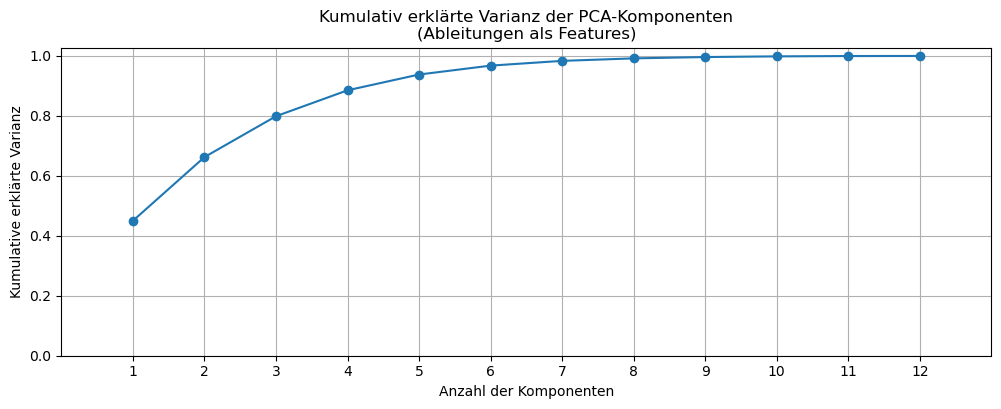

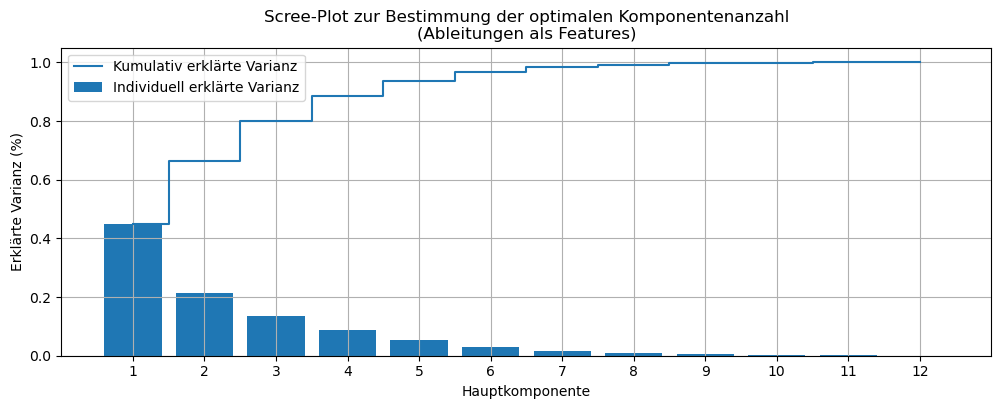

In [8]:
pca_leads_MI.plot_explained_variance(figsize=figsize)
pca_leads_MI.plot_scree_plot(figsize=figsize)

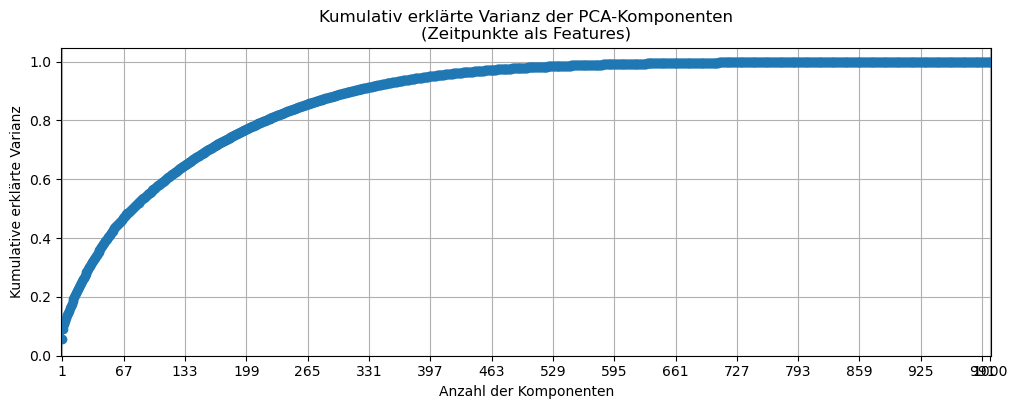

In [9]:
features = 1000
pca_time_MI = PCA_1D(n_components=features, standardize=False, feature_mode='time')

pca_time_MI.fit(X)
pca_time_MI.plot_explained_variance(figsize=figsize)

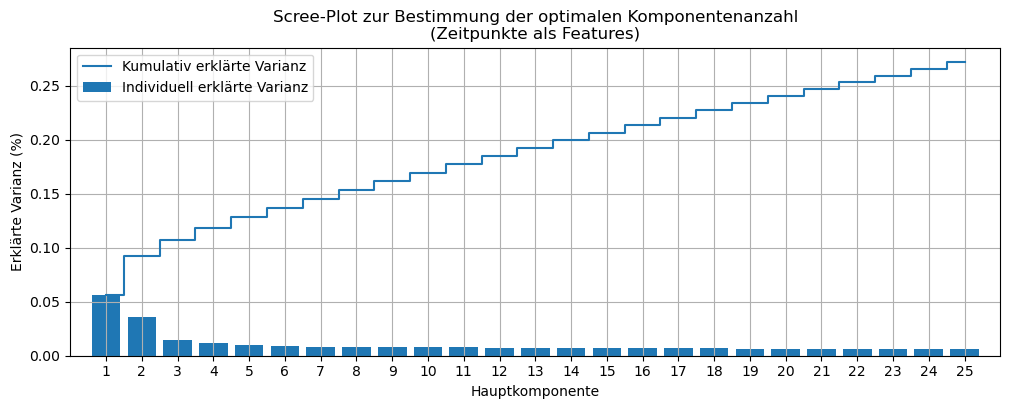

In [10]:
features = 25
pca_time_MI2 = PCA_1D(n_components=features, standardize=False, feature_mode='time')

pca_time_MI2.fit(X)
pca_time_MI2.plot_scree_plot(figsize=figsize)

## For NORM

In [11]:
figsize = (12, 4)
X = X_train_NORM

In [12]:
features = 12
pca_leads_NORM = PCA_1D(n_components=features, standardize=False, feature_mode='leads')
pca_leads_NORM.fit(X)
#X_train_pca = pca_leads.transform(X)

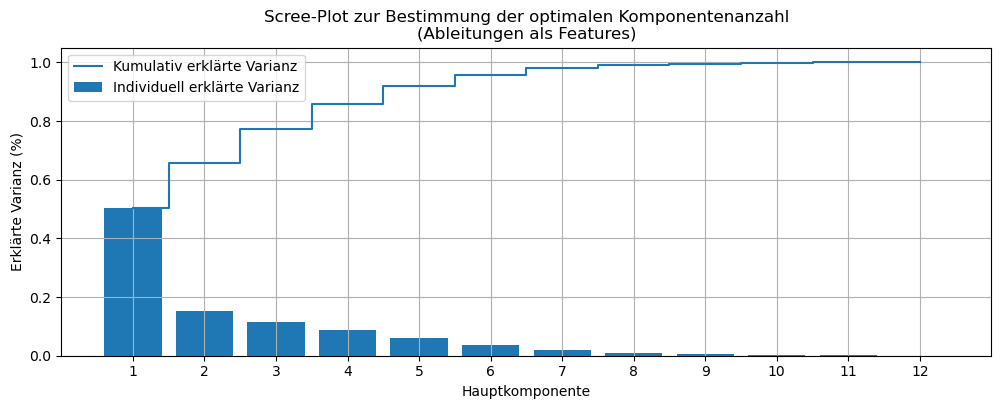

In [13]:
pca_leads_NORM.plot_scree_plot(figsize=figsize)

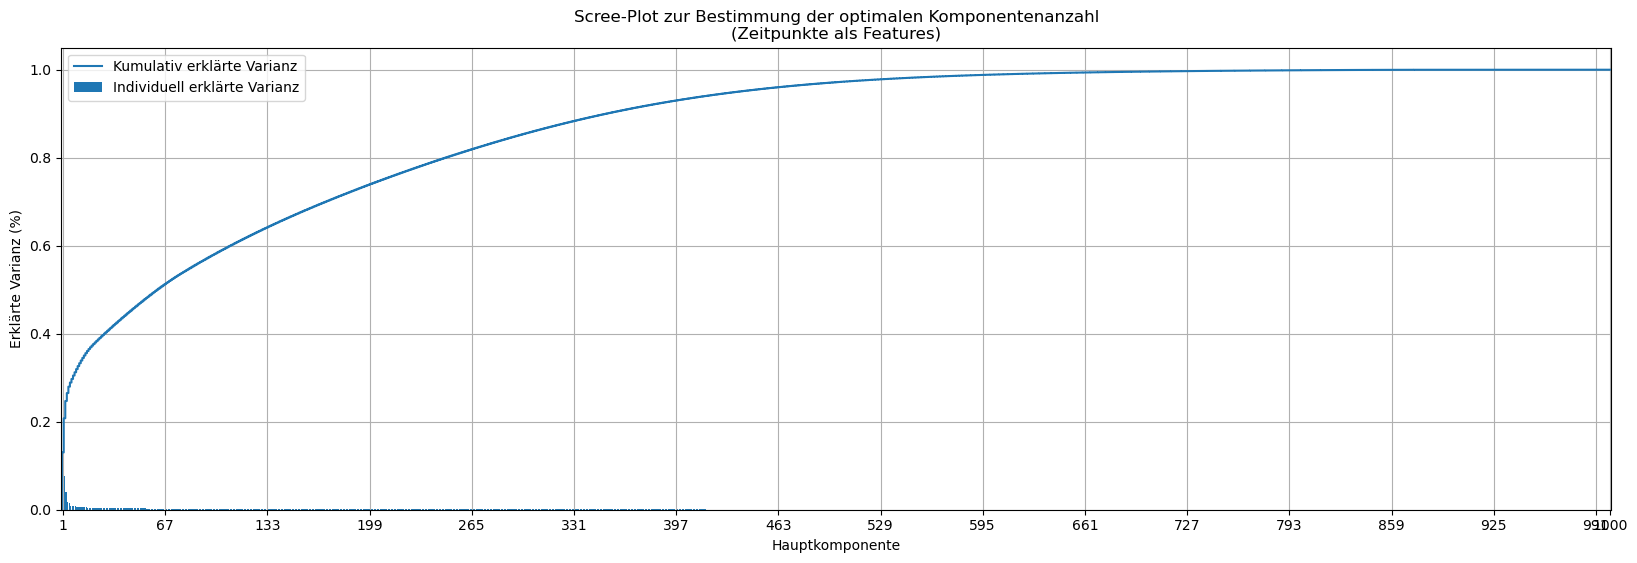

In [14]:
features = 1000
pca_time_NORM = PCA_1D(n_components=features, standardize=False, feature_mode='time')
pca_time_NORM.fit(X)
pca_time_NORM.plot_scree_plot(figsize=(20, 6))

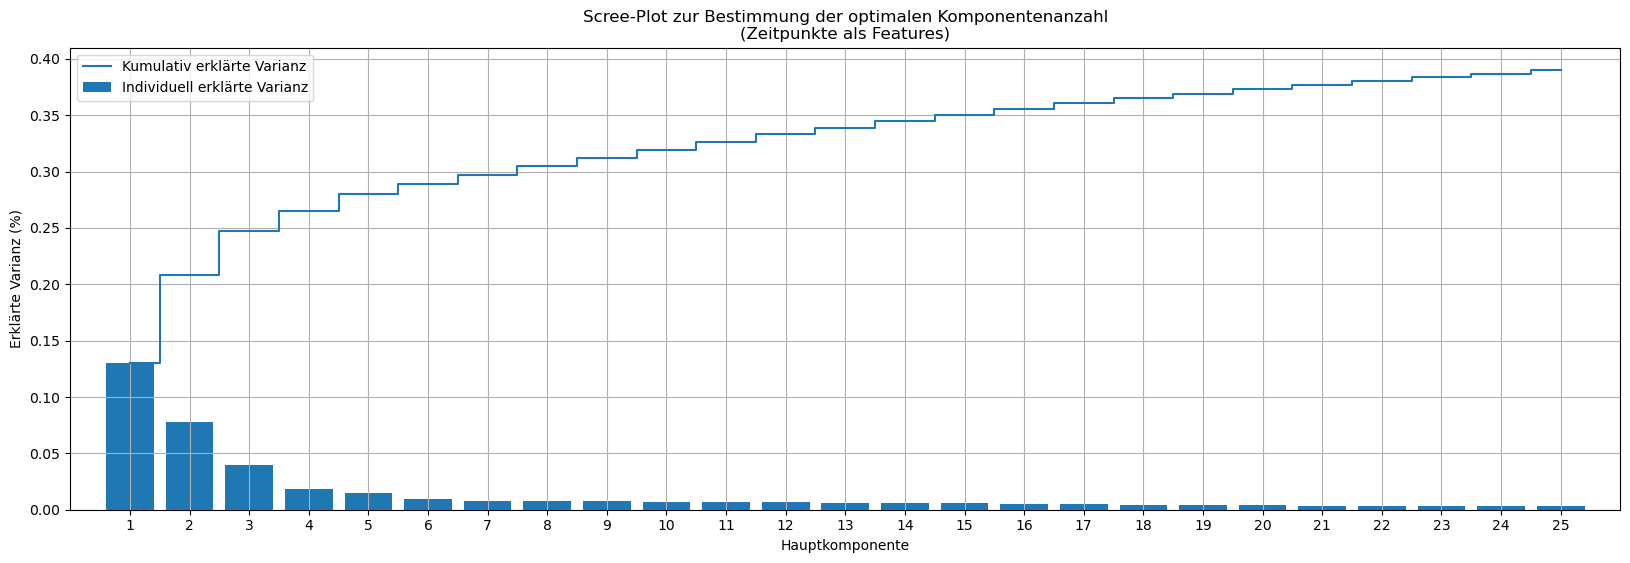

In [15]:
features = 25
pca_time_NORM2 = PCA_1D(n_components=features, standardize=False, feature_mode='time')
pca_time_NORM2.fit(X)
pca_time_NORM2.plot_scree_plot(figsize=(20, 6))

## Compare

In [16]:
pca_leads_dict = {
    'MI': pca_leads_MI,
    'NORM': pca_leads_NORM
}

pca_time_dict = {
    'MI': pca_time_MI2,
    'NORM': pca_time_NORM2
}

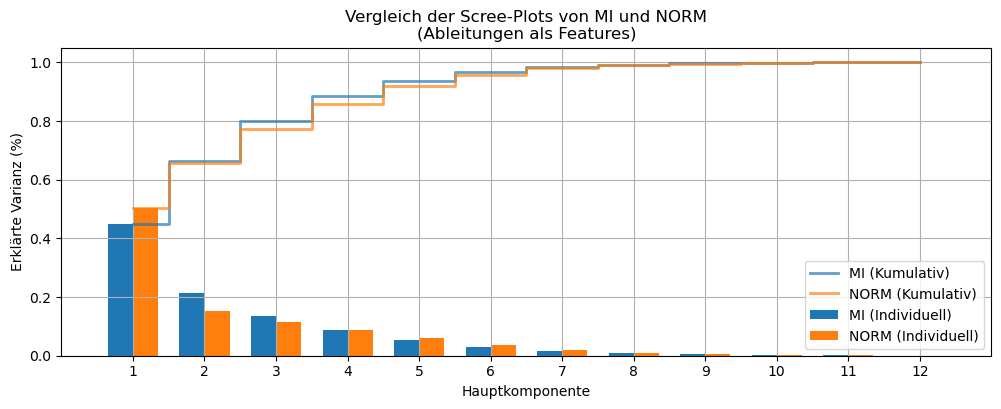

In [17]:
PCA_1D.compare_scree_plots(pca_leads_dict, figsize=(12, 4))

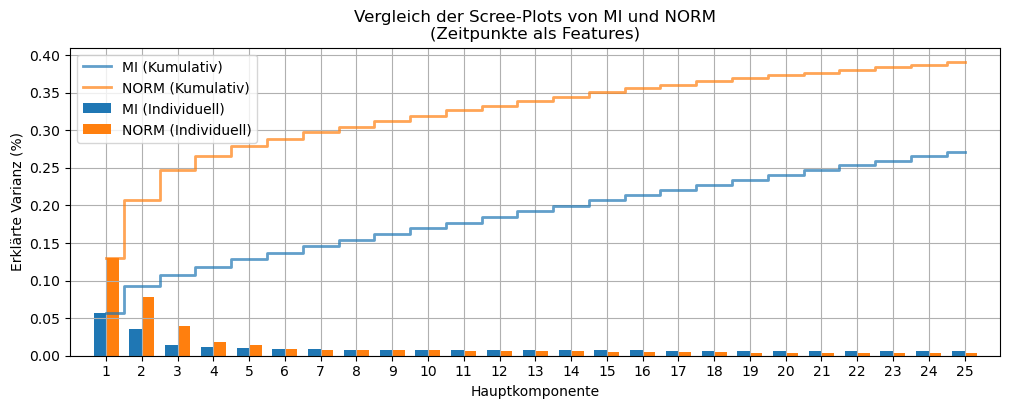

In [18]:
PCA_1D.compare_scree_plots(pca_time_dict, figsize=(12, 4))